# Entrenamiento y Evaluación de Modelos — California Housing

Target: `MedHouseVal` (valor mediano de casa, en 100k USD)  
Modelos: **XGBoost · LightGBM · CatBoost**

## 1. Imports y configuración

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.inspection import permutation_importance

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor, Pool

sns.set_theme(style='whitegrid')
SEED = 42
print(f'XGBoost {xgb.__version__} | LightGBM {lgb.__version__} | CatBoost OK')

XGBoost 3.2.0 | LightGBM 4.6.0 | CatBoost OK


## 2. Carga y preparación de datos

In [3]:
raw = fetch_california_housing(as_frame=True)
df = raw.frame

X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

FEATURES = list(X.columns)
print(f'Registros: {len(df):,}  |  Features: {FEATURES}')
df.describe().round(3)

Registros: 20,640  |  Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (16512, 8)  |  Test: (4128, 8)


## 3. Definición de modelos

In [ ]:
models = {
    'XGBoost': xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=SEED,
        verbosity=0,
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=SEED,
        verbose=-1,
    ),
    'CatBoost': CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3,
        random_seed=SEED,
        verbose=0,
        allow_writing_files=False,
    ),
}
print('Modelos definidos:', list(models.keys()))

## 4. Entrenamiento

In [6]:
trained = {}

for name, model in models.items():
    print(f'Entrenando {name}...', end=' ')
    model.fit(X_train, y_train)
    trained[name] = model
    print('listo')

print('\nEntrenamiento completado.')

Entrenando XGBoost... listo
Entrenando LightGBM... listo
Entrenando CatBoost... listo

Entrenamiento completado.


## 5. Evaluación en conjunto de test

In [7]:
def evaluate(model, X, y):
    preds = model.predict(X)
    rmse = mean_squared_error(y, preds) ** 0.5
    mae  = mean_absolute_error(y, preds)
    r2   = r2_score(y, preds)
    return {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'preds': preds}

results = {}
for name, model in trained.items():
    results[name] = evaluate(model, X_test, y_test)

metrics_df = pd.DataFrame(
    {name: {k: v for k, v in res.items() if k != 'preds'}
     for name, res in results.items()}
).T.round(4)

print('=== Métricas en Test ===')
metrics_df

=== Métricas en Test ===


,RMSE,MAE,R²
XGBoost,0.4450,0.2903,0.8489
LightGBM,0.4434,0.2909,0.8499
CatBoost,0.4715,0.3152,0.8303


## 6. Validación cruzada (5-fold)

In [8]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}

for name, model in trained.items():
    scores = cross_val_score(
        model, X, y,
        cv=kf,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    cv_results[name] = {
        'CV RMSE Mean': -scores.mean(),
        'CV RMSE Std':   scores.std()
    }
    print(f'{name}: RMSE = {-scores.mean():.4f} ± {scores.std():.4f}')

cv_df = pd.DataFrame(cv_results).T.round(4)
cv_df

XGBoost: RMSE = 0.4451 ± 0.0090
LightGBM: RMSE = 0.4452 ± 0.0095
CatBoost: RMSE = 0.4673 ± 0.0108


,CV RMSE Mean,CV RMSE Std
XGBoost,0.4451,0.0090
LightGBM,0.4452,0.0095
CatBoost,0.4673,0.0108


## 7. Comparación visual de métricas

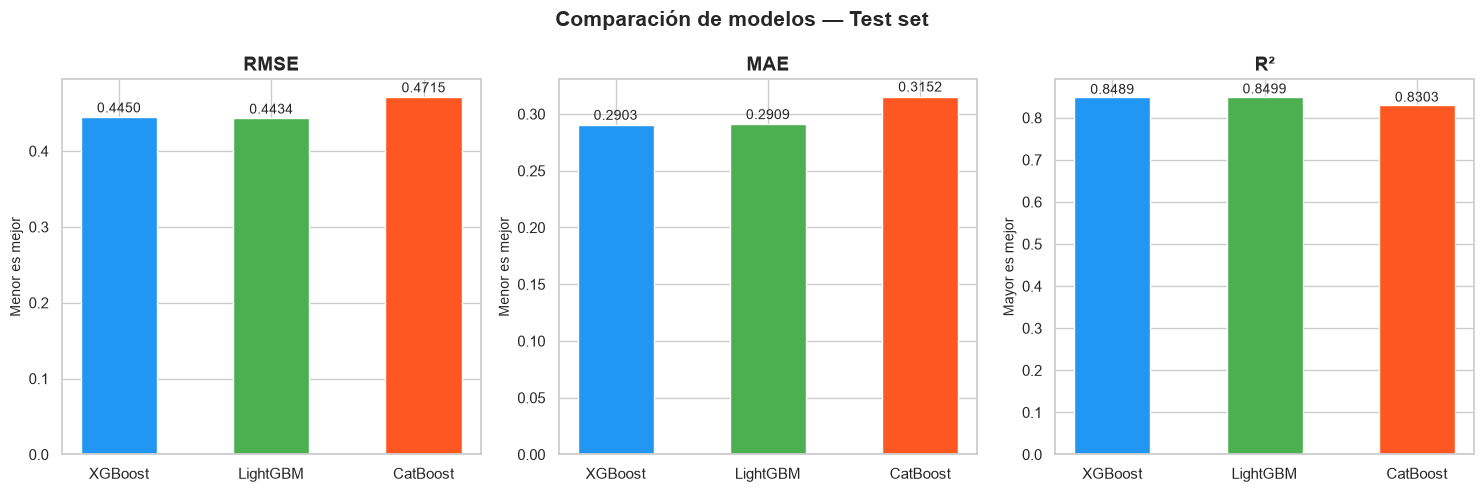

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#2196F3', '#4CAF50', '#FF5722']
model_names = list(metrics_df.index)

for ax, metric, ylabel in zip(
    axes,
    ['RMSE', 'MAE', 'R²'],
    ['Menor es mejor', 'Menor es mejor', 'Mayor es mejor']
):
    vals = metrics_df[metric].values
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (0.002 if metric != 'R²' else 0.001),
            f'{val:.4f}', ha='center', va='bottom', fontsize=10
        )

plt.suptitle('Comparación de modelos — Test set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Predicciones vs valores reales

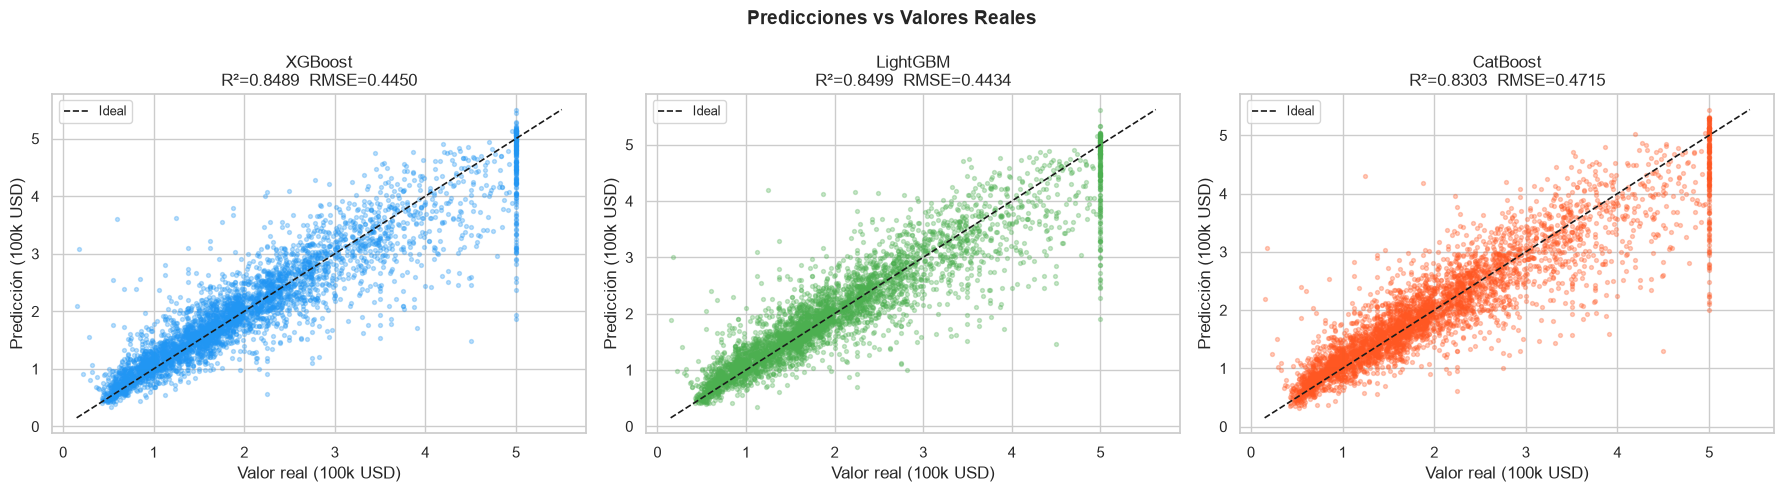

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res), color in zip(axes, results.items(), colors):
    preds = res['preds']
    ax.scatter(y_test, preds, alpha=0.3, s=8, color=color)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.2, label='Ideal')
    ax.set_xlabel('Valor real (100k USD)')
    ax.set_ylabel('Predicción (100k USD)')
    ax.set_title(f'{name}\nR²={res["R²"]:.4f}  RMSE={res["RMSE"]:.4f}',
                 fontsize=12)
    ax.legend(fontsize=9)

plt.suptitle('Predicciones vs Valores Reales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Distribución de residuos

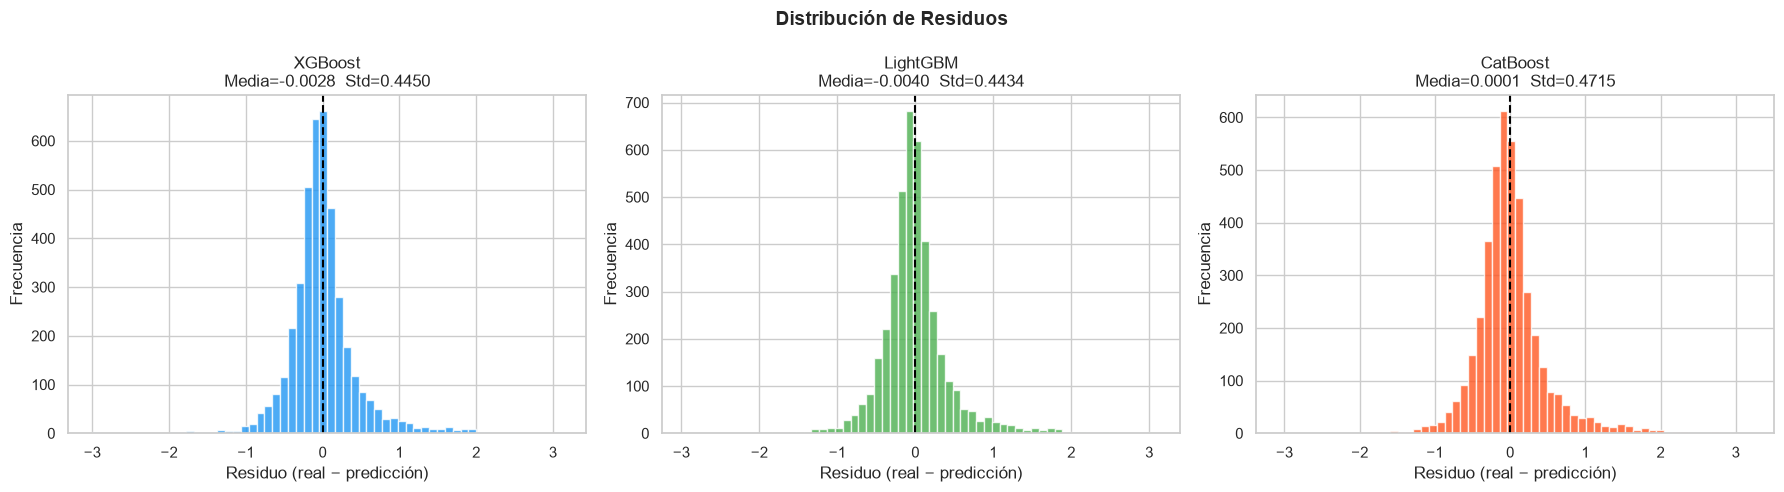

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res), color in zip(axes, results.items(), colors):
    residuals = y_test.values - res['preds']
    ax.hist(residuals, bins=60, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Residuo (real − predicción)')
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'{name}\nMedia={residuals.mean():.4f}  Std={residuals.std():.4f}',
                 fontsize=12)

plt.suptitle('Distribución de Residuos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Importancia de features

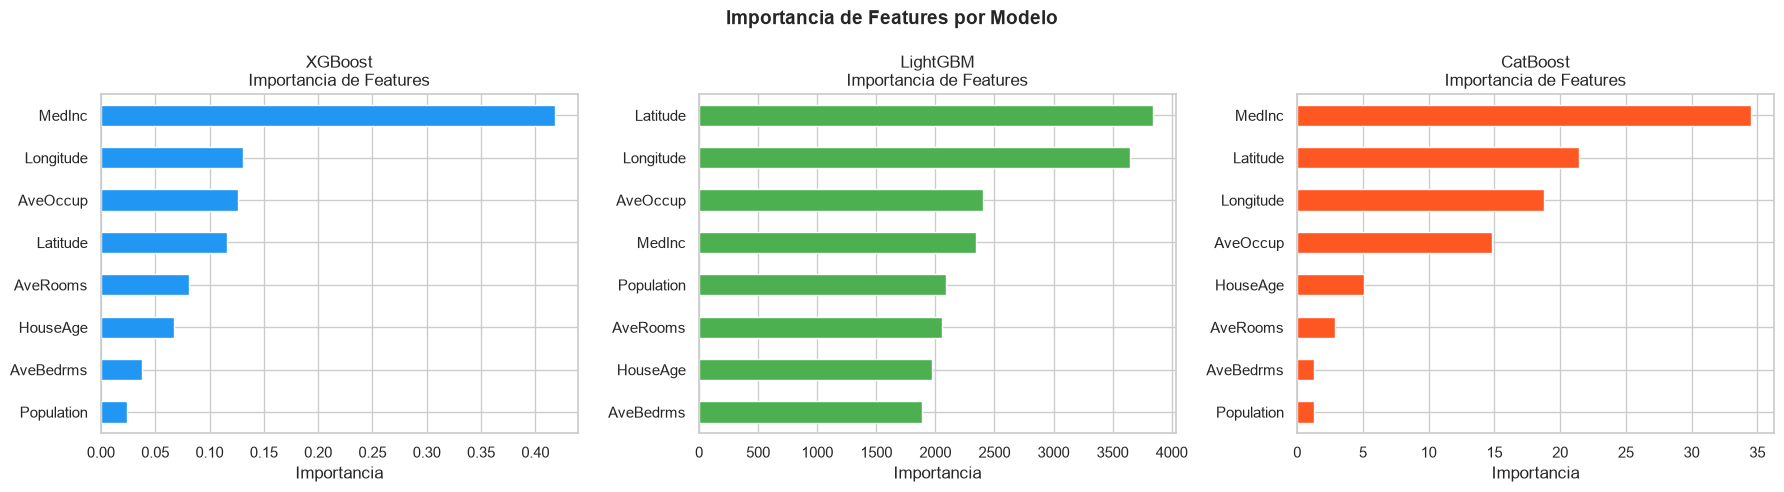

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model), color in zip(axes, trained.items(), colors):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        importances = model.get_feature_importance()

    imp_series = pd.Series(importances, index=FEATURES).sort_values(ascending=True)
    imp_series.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'{name}\nImportancia de Features', fontsize=12)
    ax.set_xlabel('Importancia')

plt.suptitle('Importancia de Features por Modelo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Resumen final

In [13]:
summary = metrics_df.copy()
summary['CV RMSE'] = cv_df['CV RMSE Mean']
summary['CV RMSE ±'] = cv_df['CV RMSE Std']

best_rmse  = summary['RMSE'].idxmin()
best_r2    = summary['R²'].idxmax()
best_cv    = summary['CV RMSE'].idxmin()

print('=== Resumen de Resultados ===')
print(summary.to_string())
print(f'\nMejor RMSE (test):  {best_rmse}')
print(f'Mejor R² (test):    {best_r2}')
print(f'Mejor CV RMSE:      {best_cv}')

=== Resumen de Resultados ===
            RMSE     MAE      R²  CV RMSE  CV RMSE ±
XGBoost   0.4450  0.2903  0.8489   0.4451     0.0090
LightGBM  0.4434  0.2909  0.8499   0.4452     0.0095
CatBoost  0.4715  0.3152  0.8303   0.4673     0.0108

Mejor RMSE (test):  LightGBM
Mejor R² (test):    LightGBM
Mejor CV RMSE:      XGBoost


## 12. Exportación del modelo ganador (LightGBM)

In [14]:
import pickle
import json
from pathlib import Path
from datetime import datetime

MODELS_DIR = Path('..') / 'models'
MODELS_DIR.mkdir(exist_ok=True)

best_model = trained['LightGBM']
model_path = MODELS_DIR / 'lightgbm_california.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

# Metadatos para reproducibilidad y carga posterior
metadata = {
    'model': 'LightGBM',
    'target': 'MedHouseVal',
    'features': FEATURES,
    'params': best_model.get_params(),
    'metrics': {
        'test_rmse': float(results['LightGBM']['RMSE']),
        'test_mae':  float(results['LightGBM']['MAE']),
        'test_r2':   float(results['LightGBM']['R²']),
        'cv_rmse_mean': float(cv_results['LightGBM']['CV RMSE Mean']),
        'cv_rmse_std':  float(cv_results['LightGBM']['CV RMSE Std']),
    },
    'exported_at': datetime.now().isoformat(),
    'train_size': int(X_train.shape[0]),
    'test_size':  int(X_test.shape[0]),
}

meta_path = MODELS_DIR / 'lightgbm_california_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Modelo guardado en:   {model_path.resolve()}')
print(f'Metadatos guardados en: {meta_path.resolve()}')
print(f'\nVerificación de carga:')
with open(model_path, 'rb') as f:
    loaded = pickle.load(f)
sample_pred = loaded.predict(X_test.head(3))
print(f'  Predicciones de muestra: {sample_pred.round(4)}')

Modelo guardado en:   C:\Users\Alejandro Silva\Documents\Proyectos\MLops\devops-appml\models\lightgbm_california.pkl
Metadatos guardados en: C:\Users\Alejandro Silva\Documents\Proyectos\MLops\devops-appml\models\lightgbm_california_metadata.json

Verificación de carga:
  Predicciones de muestra: [0.5344 1.1574 4.9096]
